IMPORTS

In [ ]:
pip install pandas numpy matplotlib seaborn nltk textblob sentence-transformers wefe scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 16.9 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-

In [ ]:
from gensim.models import KeyedVectors
from wefe.word_embedding_model import WordEmbeddingModel
from wefe.metrics import WEAT
from wefe.query import Query

import gensim.downloader as api
glove = api.load('glove-wiki-gigaword-100')

we_model = WordEmbeddingModel(glove, 'glove')

# Define WEAT query manually
query = Query(
    target_sets=[['man', 'male', 'boy'], ['woman', 'female', 'girl']],
    attribute_sets=[['doctor', 'engineer', 'scientist'],
                    ['nurse', 'teacher', 'receptionist']],
    target_sets_names=['Male', 'Female'],
    attribute_sets_names=['STEM', 'Care']
)

weat = WEAT()
result = weat.run_query(query, we_model)
print(result)

[==================================================] 100.0% 128.1/128.1MB downloaded
{'query_name': 'Male and Female wrt STEM and Care', 'result': 0.2602653975288074, 'weat': 0.2602653975288074, 'effect_size': 1.2314793170659728, 'p_value': nan}


In [ ]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

df = pd.read_csv("dataset.csv")

text_data = df['generated_text'].astype(str).tolist()
full_text = " ".join(text_data)
clean_text = re.sub(r'[^a-zA-Z\s]', '', full_text).lower()

words = clean_text.split()
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w not in stop_words and len(w) > 2]

word_counts = Counter(filtered_words)
most_common_words = word_counts.most_common(50)

print("\nTop 50 Most Frequent Words:")
for word, freq in most_common_words:
    print(f"{word}: {freq}")

most_frequent_word_list = [w for w, _ in most_common_words]
print("\nMost frequent words (list):")
print(most_frequent_word_list)



Top 50 Most Frequent Words:
nan: 404
india: 179
indian: 120
like: 111
government: 90
people: 84
system: 75
trade: 69
land: 68
british: 68
century: 65
local: 64
also: 63
water: 62
including: 61
state: 59
economic: 56
many: 55
resources: 55
often: 55
indias: 54
empire: 54
life: 51
one: 50
include: 47
goods: 47
called: 43
power: 42
used: 41
activities: 41
time: 39
years: 39
cultural: 39
period: 39
political: 38
military: 38
mughal: 38
climate: 37
ancient: 37
rulers: 37
natural: 36
two: 36
new: 35
services: 35
across: 34
sabha: 34
markets: 34
large: 33
leading: 33
due: 33

Most frequent words (list):
['nan', 'india', 'indian', 'like', 'government', 'people', 'system', 'trade', 'land', 'british', 'century', 'local', 'also', 'water', 'including', 'state', 'economic', 'many', 'resources', 'often', 'indias', 'empire', 'life', 'one', 'include', 'goods', 'called', 'power', 'used', 'activities', 'time', 'years', 'cultural', 'period', 'political', 'military', 'mughal', 'climate', 'ancient', 'rule

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LOAD DATA

In [ ]:
# Load dataset (id, class, subject, chapter, passage_no, text, generated_text)
df = pd.read_csv("/content/dataset.csv")

# Basic cleaning
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[“”]', '"', text)
    text = re.sub(r"[’‘]", "'", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)
df['generated_text'] = df['generated_text'].apply(clean_text)


EMBEDDING GENERATION

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
df['emb_text'] = df['text'].apply(lambda x: model.encode(x))
df['emb_generated'] = df['generated_text'].apply(lambda x: model.encode(x))

# Semantic similarity between human and AI text
df['semantic_similarity'] = df.apply(lambda r: cosine_similarity(
    [r['emb_text']], [r['emb_generated']])[0][0], axis=1)


PRONOUN AND ROLE DISTRIBUTION ANALYSIS

In [ ]:
def count_pronouns(text):
    text = text.lower()
    male = len(re.findall(r'\bhe\b|\bhim\b|\bhis\b', text))
    female = len(re.findall(r'\bshe\b|\bher\b', text))
    return male, female

df[['male_h', 'female_h']] = df['text'].apply(lambda t: pd.Series(count_pronouns(t)))
df[['male_ai', 'female_ai']] = df['generated_text'].apply(lambda t: pd.Series(count_pronouns(t)))

# Compute pronoun bias ratio (male / total)
df['male_ratio_h'] = df['male_h'] / (df['male_h'] + df['female_h'] + 1)
df['male_ratio_ai'] = df['male_ai'] / (df['male_ai'] + df['female_ai'] + 1)


SENTIMENT ANALYSIS

In [ ]:
from textblob import TextBlob
def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

df['sentiment_h'] = df['text'].apply(get_sentiment)
df['sentiment_ai'] = df['generated_text'].apply(get_sentiment)

df['sentiment_diff'] = df['sentiment_ai'] - df['sentiment_h']


WEAT

In [ ]:
from gensim.models import KeyedVectors
from wefe.word_embedding_model import WordEmbeddingModel

# You can use a pretrained model like GloVe or Google News Word2Vec
# Example: download 'glove-wiki-gigaword-100'
import gensim.downloader as api
glove = api.load('glove-wiki-gigaword-100')

we_model = WordEmbeddingModel(glove, 'glove')

# Define WEAT query
query = Query(
    target_sets=[['man', 'male', 'boy'], ['woman', 'female', 'girl']],
    attribute_sets=[['doctor', 'engineer', 'scientist'],
                    ['nurse', 'teacher', 'receptionist']],
    target_sets_names=['Male', 'Female'],
    attribute_sets_names=['STEM', 'Care']
)

weat = WEAT()
result = weat.run_query(query, we_model)
print(result)


{'query_name': 'Male and Female wrt STEM and Care', 'result': 0.2602653975288074, 'weat': 0.2602653975288074, 'effect_size': 1.2314793170659728, 'p_value': nan}


In [ ]:
# ======================= IMPORTS =======================
import pandas as pd
from gensim.models import KeyedVectors
from wefe.word_embedding_model import WordEmbeddingModel
from wefe.metrics import WEAT
from wefe.query import Query
import gensim.downloader as api

# ======================= LOAD MODEL =======================
print("Loading GloVe embeddings...")
glove = api.load('glove-wiki-gigaword-100')   # or use 'glove-wiki-gigaword-300' for higher dimensional accuracy
we_model = WordEmbeddingModel(glove, 'glove')
print("Model loaded successfully ✅")

# ======================= DEFINE WEAT QUERIES =======================

# 1️⃣ Gender Bias
gender_query = Query(
    target_sets=[['man', 'male', 'boy', 'he', 'him', 'father', 'son', 'husband'],
                 ['woman', 'female', 'girl', 'she', 'her', 'mother', 'daughter', 'wife']],
    attribute_sets=[['strong', 'brave', 'decisive', 'powerful', 'assertive', 'leader'],
                    ['kind', 'gentle', 'nurturing', 'compassionate', 'empathetic', 'soft']],
    target_sets_names=['Male', 'Female'],
    attribute_sets_names=['Dominant', 'Nurturing']
)

# 2️⃣ Religion Bias
religion_query = Query(
    target_sets=[['ram', 'krishna', 'temple', 'puja', 'gita', 'hindu'],
                 ['allah', 'muhammad', 'mosque', 'quran', 'eid', 'muslim']],
    attribute_sets=[['peace', 'truth', 'kindness', 'virtue', 'respect', 'compassion'],
                    ['violence', 'evil', 'terror', 'wrong', 'fanatic', 'crime']],
    target_sets_names=['Hindu', 'Muslim'],
    attribute_sets_names=['Positive', 'Negative']
)

# 3️⃣ Caste Bias
caste_query = Query(
    target_sets=[['brahmin', 'kshatriya', 'vaishya', 'upper', 'elite'],
                 ['dalit', 'shudra', 'sc', 'st', 'lower', 'backward']],
    attribute_sets=[['educated', 'respected', 'wealthy', 'leader', 'authority'],
                    ['poor', 'labor', 'excluded', 'marginalized', 'servant']],
    target_sets_names=['UpperCaste', 'LowerCaste'],
    attribute_sets_names=['Privileged', 'Disadvantaged']
)

# 4️⃣ Regional Bias
regional_query = Query(
    target_sets=[['urban', 'city', 'metropolitan', 'developed', 'modern'],
                 ['rural', 'village', 'agricultural', 'traditional', 'undeveloped']],
    attribute_sets=[['educated', 'wealthy', 'advanced', 'progressive', 'clean'],
                    ['poor', 'backward', 'illiterate', 'dirty', 'isolated']],
    target_sets_names=['Urban', 'Rural'],
    attribute_sets_names=['Positive', 'Negative']
)

# 5️⃣ Education Bias
education_query = Query(
    target_sets=[['educated', 'literate', 'scholar', 'teacher', 'student'],
                 ['uneducated', 'illiterate', 'ignorant', 'dropout', 'uninformed']],
    attribute_sets=[['intelligent', 'wise', 'successful', 'modern', 'capable'],
                    ['stupid', 'foolish', 'poor', 'backward', 'slow']],
    target_sets_names=['Educated', 'Uneducated'],
    attribute_sets_names=['Positive', 'Negative']
)

# 6️⃣ Economic Bias
economic_query = Query(
    target_sets=[['rich', 'wealthy', 'elite', 'affluent', 'privileged'],
                 ['poor', 'needy', 'labor', 'marginalized', 'underprivileged']],
    attribute_sets=[['happy', 'respected', 'powerful', 'successful', 'influential'],
                    ['sad', 'weak', 'struggling', 'ignored', 'dependent']],
    target_sets_names=['Rich', 'Poor'],
    attribute_sets_names=['Positive', 'Negative']
)

# ======================= RUN WEAT ON ALL QUERIES =======================
weat = WEAT()
queries = [
    ("Gender Bias", gender_query),
    ("Religion Bias", religion_query),
    ("Caste Bias", caste_query),
    ("Regional Bias", regional_query),
    ("Education Bias", education_query),
    ("Economic Bias", economic_query)
]

results = []

for bias_name, q in queries:
    print(f"\n===== Running WEAT: {bias_name} ({q.target_sets_names[0]} vs {q.target_sets_names[1]}) =====")
    try:
        result = weat.run_query(q, we_model, calculate_p_value=True, p_value_iterations=5000)
        results.append({
            "Bias Type": bias_name,
            "Target 1": q.target_sets_names[0],
            "Target 2": q.target_sets_names[1],
            "Attribute 1": q.attribute_sets_names[0],
            "Attribute 2": q.attribute_sets_names[1],
            "Effect Size": result.get("effect_size"),
            "WEAT": result.get("weat"),
            "P-Value": result.get("p_value")
        })
        print(result)
    except Exception as e:
        print(f"Error running {bias_name}: {e}")

# ======================= SAVE RESULTS TO CSV =======================
df_results = pd.DataFrame(results)
df_results.to_csv("weat_bias_results.csv", index=False)
print("\n✅ All WEAT tests completed. Results saved as 'weat_bias_results.csv'")

# Display the summary table
print("\nSummary of WEAT Bias Test Results:")
print(df_results)


Loading GloVe embeddings...
Model loaded successfully ✅

===== Running WEAT: Gender Bias (Male vs Female) =====
{'query_name': 'Male and Female wrt Dominant and Nurturing', 'result': 0.30375461342434085, 'weat': 0.30375461342434085, 'effect_size': 0.7890325915868173, 'p_value': 0.05358928214357129}

===== Running WEAT: Religion Bias (Hindu vs Muslim) =====
{'query_name': 'Hindu and Muslim wrt Positive and Negative', 'result': 0.3125098186234634, 'weat': 0.3125098186234634, 'effect_size': 0.5845632569466797, 'p_value': 0.16076784643071385}

===== Running WEAT: Caste Bias (UpperCaste vs LowerCaste) =====
{'query_name': 'UpperCaste and LowerCaste wrt Privileged and Disadvantaged', 'result': 0.34720506034791476, 'weat': 0.34720506034791476, 'effect_size': 0.728502199841208, 'p_value': 0.11617676464707058}

===== Running WEAT: Regional Bias (Urban vs Rural) =====
{'query_name': 'Urban and Rural wrt Positive and Negative', 'result': 0.4976615339517592, 'weat': 0.4976615339517592, 'effect_siz

COUNTERFACTUAL TESTING

In [ ]:
def gender_swap(text):
    swaps = {
        r'\bhe\b': 'she', r'\bhim\b': 'her', r'\bhis\b': 'her',
        r'\bshe\b': 'he', r'\bher\b': 'him'
    }
    swapped = text.lower()
    for k, v in swaps.items():
        swapped = re.sub(k, v, swapped)
    return swapped

df['text_swapped'] = df['text'].apply(gender_swap)
df['sentiment_swapped'] = df['text_swapped'].apply(get_sentiment)
df['sentiment_change'] = df['sentiment_swapped'] - df['sentiment_h']


LEXICAL DIVERSITY

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

def lexical_diversity(text):
    tokens = word_tokenize(str(text).lower())
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df['lexical_div_h'] = df['text'].apply(lexical_diversity)
df['lexical_div_ai'] = df['generated_text'].apply(lexical_diversity)
df['lexical_diff'] = df['lexical_div_ai'] - df['lexical_div_h']

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


VISUALISATION

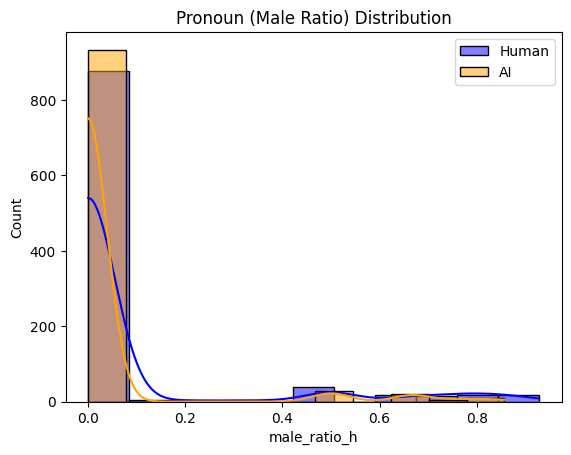

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['male_ratio_h'], color='blue', label='Human', kde=True)
sns.histplot(df['male_ratio_ai'], color='orange', label='AI', kde=True)
plt.title("Pronoun (Male Ratio) Distribution")
plt.legend()
plt.show()


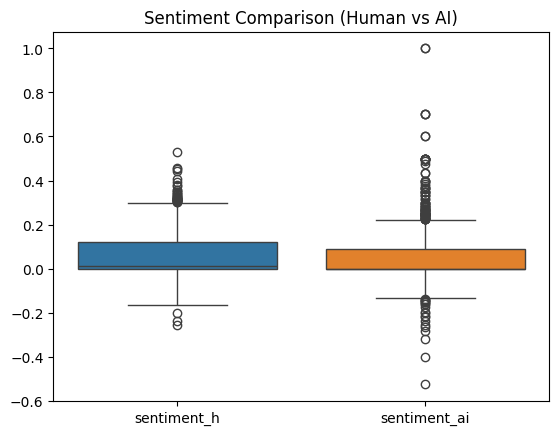

In [ ]:
sns.boxplot(data=df[['sentiment_h','sentiment_ai']])
plt.title("Sentiment Comparison (Human vs AI)")
plt.show()


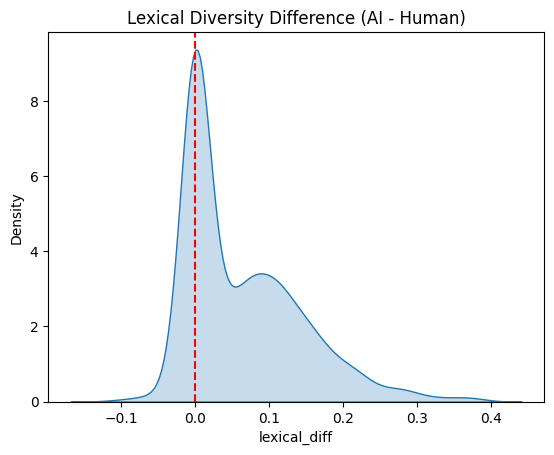

In [ ]:
sns.kdeplot(df['lexical_diff'], fill=True)
plt.title("Lexical Diversity Difference (AI - Human)")
plt.axvline(0, color='red', linestyle='--')
plt.show()


RESULTS

In [ ]:
summary_cols = [
    'id', 'class', 'subject', 'chapter',
    'male_ratio_h', 'male_ratio_ai',
    'sentiment_h', 'sentiment_ai', 'sentiment_diff',
    'lexical_div_h', 'lexical_div_ai', 'lexical_diff',
    'semantic_similarity'
]
df[summary_cols].to_csv("bias_analysis_results.csv", index=False)
print("✅ Results saved to bias_analysis_results.csv")


✅ Results saved to bias_analysis_results.csv


BIAS INDEX

In [ ]:
# Normalize and aggregate (weights optional)
df['Bias_Index'] = (
    abs(df['male_ratio_h'] - df['male_ratio_ai']) * 0.4 +
    abs(df['sentiment_diff']) * 0.3 +
    abs(df['lexical_diff']) * 0.3
)


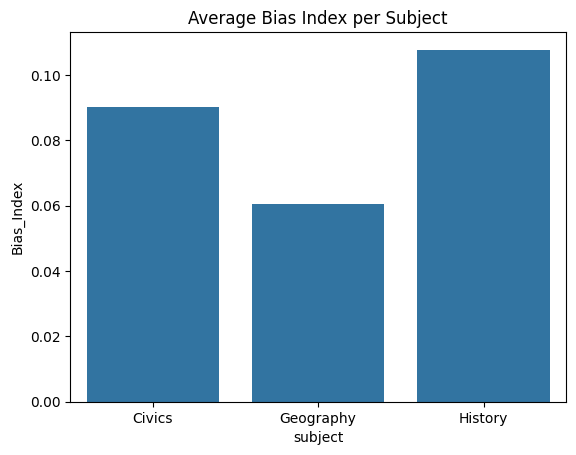

In [ ]:
summary = df.groupby('subject')['Bias_Index'].mean().reset_index()
sns.barplot(x='subject', y='Bias_Index', data=summary)
plt.title("Average Bias Index per Subject")
plt.show()
